# Desafio 16 – Risco de Crédito (P2 – Versão Corrigida)
**Grupo 16 | Domínio: Financeiro | Tipo: Classificação Binária**

Dataset: [German Credit Data – Kaggle](https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk)

| Aluno | RA |
|---|---|
| Renan Gonçalves Rodrigues | **2040669** |
| Sofhia Kobor Dias | **2095896** |

---
### Correções aplicadas em relação à P1
| Problema (P1) | Correção (P2) |
|---|---|
| `LabelEncoder` em variáveis nominais (`Sex`, `Housing`, `Purpose`) | Substituído por `OneHotEncoder` via `ColumnTransformer` |
| `StandardScaler` aplicado sobre colunas já codificadas ordinalmente (inteiros) | Scaler aplicado apenas sobre numéricas contínuas (`Age`, `Credit amount`, `Duration`) |
| Métricas interpretadas para a classe `good` (majoritária) | Métricas reportadas para `bad` (classe de interesse de negócio) com `pos_label=1` |
| Inconsistência entre notebook e relatório | Notebook re-executado do zero; relatório atualizado conforme resultados finais |
| Modelo final não salvo | Modelo final salvo em `model/modelo_final.joblib` com pipeline completo |

## 0. Imports e Configuração

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('Imports concluídos.')

Imports concluídos.


## 1. Carregamento do Dataset

> **Como obter o arquivo:**
> Acesse: https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk  
> Faça download e coloque `german_credit_data.csv` na mesma pasta deste notebook.
>
> O arquivo deve conter a coluna `Risk` (good/bad).

In [ ]:
CSV_PATH = 'german_credit_data.csv'

df_raw = pd.read_csv(CSV_PATH, index_col=0)
print(f'Dataset carregado: {df_raw.shape}')
print('\nDistribuição da variável alvo:')
print(df_raw['Risk'].value_counts())
print()
print(df_raw['Risk'].value_counts(normalize=True).map('{:.1%}'.format))
df_raw.head()

Dataset carregado: (1000, 10)

Distribuição da variável alvo:
Risk
good    700
bad     300
Name: count, dtype: int64

Risk
good    70.0%
bad     30.0%
Name: proportion, dtype: object


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [ ]:
print('=== Informações gerais ===')
df_raw.info()
print('\n=== Valores ausentes ===')
print(df_raw.isnull().sum())
print('\n=== Estatísticas descritivas ===')
df_raw.describe(include='all').T

=== Informações gerais ===
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 85.9+ KB

=== Valores ausentes ===
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dty

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Risk,1000,2,good,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Etapa 1 – Análise Exploratória (EDA)

### 1.1 Distribuição da Variável Alvo (Risk)

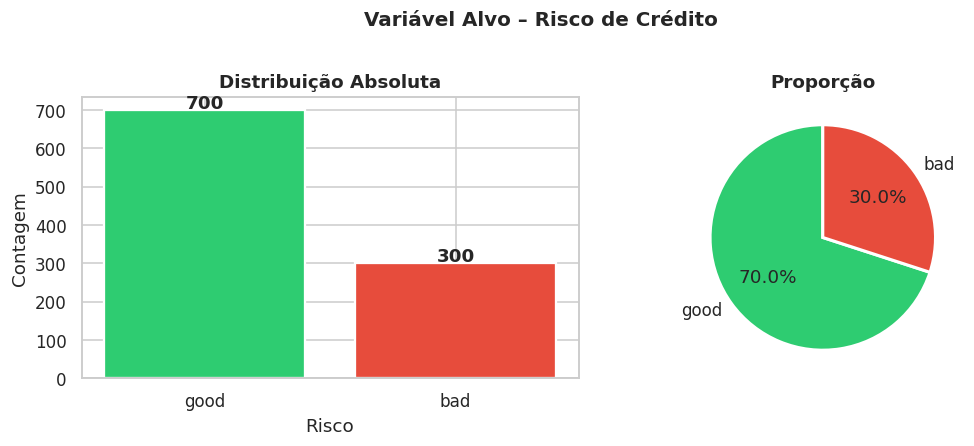


Interpretação: O dataset é desbalanceado — 70% 'good' e 30% 'bad'.
Esse desequilíbrio justifica o uso de AUC-ROC como métrica principal
e o foco nas métricas da classe 'bad' (risco real de negócio).



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts = df_raw['Risk'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ECC71','#E74C3C'],
            edgecolor='white', linewidth=1.5)
for i,(k,v) in enumerate(counts.items()):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Distribuição Absoluta', fontweight='bold')
axes[0].set_xlabel('Risco'); axes[0].set_ylabel('Contagem')
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ECC71','#E74C3C'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Proporção', fontweight='bold')
plt.suptitle('Variável Alvo – Risco de Crédito', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/eda_target.png', bbox_inches='tight')
plt.show()
print("""
Interpretação: O dataset é desbalanceado — 70% 'good' e 30% 'bad'.
Esse desequilíbrio justifica o uso de AUC-ROC como métrica principal
e o foco nas métricas da classe 'bad' (risco real de negócio).
""")

### 1.2 Variáveis Numéricas por Risco

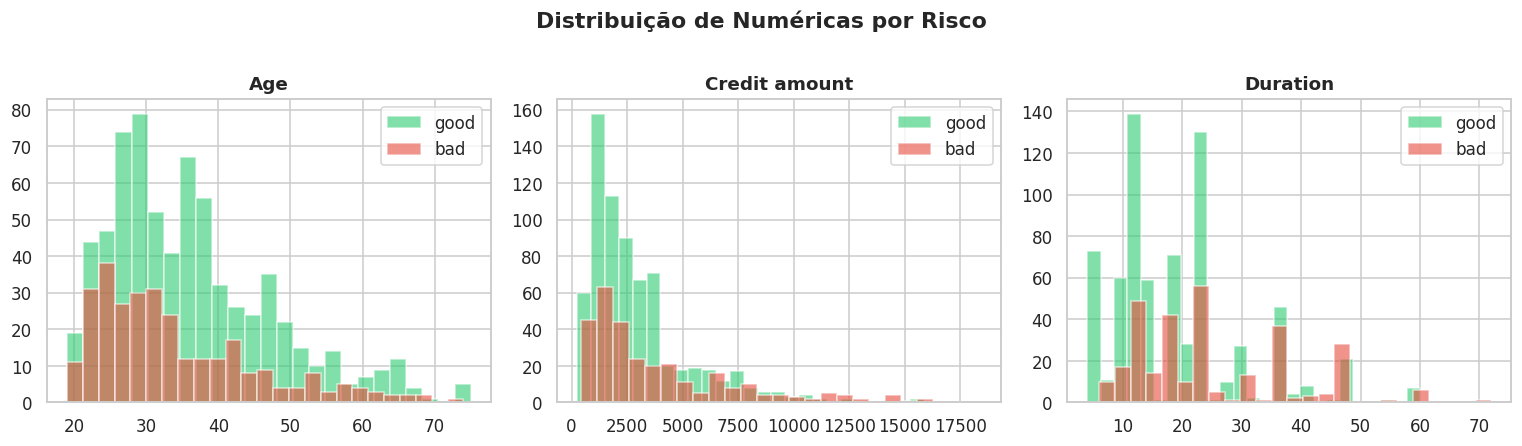


Interpretação:
- Duration: créditos de prazo mais longo concentram maior proporção de 'bad risk'.
- Credit amount: valores mais altos associados a maior risco.
- Age: jovens (20-30 anos) apresentam taxa de inadimplência levemente maior.



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Age','Credit amount','Duration']):
    for label, color in [('good','#2ECC71'),('bad','#E74C3C')]:
        ax.hist(df_raw[df_raw['Risk']==label][col].dropna(),
                bins=25, alpha=0.6, color=color, label=label)
    ax.set_title(col, fontweight='bold'); ax.legend()
plt.suptitle('Distribuição de Numéricas por Risco', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/eda_num.png', bbox_inches='tight')
plt.show()
print("""
Interpretação:
- Duration: créditos de prazo mais longo concentram maior proporção de 'bad risk'.
- Credit amount: valores mais altos associados a maior risco.
- Age: jovens (20-30 anos) apresentam taxa de inadimplência levemente maior.
""")

### 1.3 Taxa de Inadimplência por Categoria

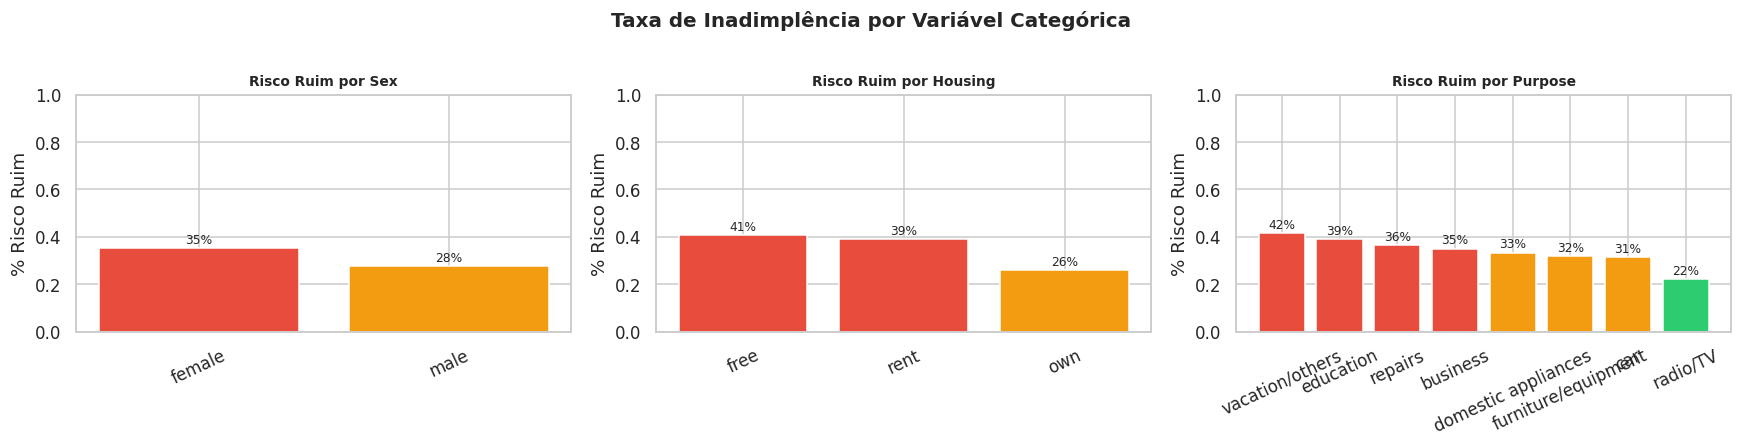


Interpretação:
- Purpose: 'vacation/others' e 'education' têm as maiores taxas de inadimplência.
- Housing: solicitantes sem moradia própria ('free') apresentam risco levemente maior.
- Sex: diferença observada, mas requer cautela ética (ver seção 4.3).



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Sex','Housing','Purpose']):
    rr = (df_raw.groupby(col)['Risk']
          .apply(lambda x:(x=='bad').mean())
          .sort_values(ascending=False).reset_index())
    rr.columns = [col,'bad_rate']
    bars = ax.bar(rr[col].astype(str), rr['bad_rate'],
                  color=['#E74C3C' if r>0.35 else '#F39C12' if r>0.25 else '#2ECC71'
                         for r in rr['bad_rate']])
    ax.set_title(f'Risco Ruim por {col}', fontweight='bold', fontsize=9)
    ax.set_ylabel('% Risco Ruim'); ax.set_ylim(0,1); ax.tick_params(axis='x',rotation=25)
    for bar,val in zip(bars,rr['bad_rate']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{val:.0%}', ha='center', fontsize=8)
plt.suptitle('Taxa de Inadimplência por Variável Categórica', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/eda_cat.png', bbox_inches='tight')
plt.show()
print("""
Interpretação:
- Purpose: 'vacation/others' e 'education' têm as maiores taxas de inadimplência.
- Housing: solicitantes sem moradia própria ('free') apresentam risco levemente maior.
- Sex: diferença observada, mas requer cautela ética (ver seção 4.3).
""")

## Etapa 2 – Pré-processamento

### Decisões corrigidas em relação à P1

**Problema 1 — LabelEncoder em variáveis nominais:**  
`Sex`, `Housing` e `Purpose` são variáveis **nominais** (sem ordem natural). Usar `LabelEncoder` atribui
números arbitrários (ex: 0, 1, 2) que induzem o modelo a tratar categorias como se tivessem ordem
hierárquica. A correção é `OneHotEncoder`, que cria colunas binárias independentes para cada categoria.

**Problema 2 — StandardScaler sobre colunas ordinais inteiras:**  
`Saving accounts` e `Checking account` foram mapeadas para inteiros ordinais (0–4). Normalizar
essas colunas destrói a interpretabilidade ordinal e pode distorcer a relação aprendida. O scaler
agora é aplicado apenas sobre as numéricas contínuas: `Age`, `Credit amount`, `Duration`.

**Problema 3 — Classe positiva nas métricas:**  
O target foi recodificado para `bad=1` (classe positiva), pois o objetivo de negócio é detectar
inadimplentes. Precisão, Recall e F1 agora medem desempenho real de interesse.

In [ ]:
df = df_raw.copy()

# 2.1 Tratamento de valores ausentes
# Saving accounts e Checking account: NaN = sem conta = categoria 'none'
for col in ['Saving accounts', 'Checking account']:
    df[col] = df[col].fillna('none')

# 2.2 Target: bad=1 (classe positiva de interesse), good=0
# CORREÇÃO P2: anteriormente 'good'=1, invertendo o foco de negócio
df['Risk'] = (df['Risk'] == 'bad').astype(int)
print(f"Distribuição do target corrigido — bad=1, good=0:")
print(df['Risk'].value_counts())

# 2.3 Separação de features por tipo
# Ordinais (há ordem natural — mapeamento manual)
ordinal_cols = ['Saving accounts', 'Checking account']
ordinal_categories = [
    ['none', 'little', 'moderate', 'quite rich', 'rich'],
    ['none', 'little', 'moderate', 'rich'],
]

# Nominais (sem ordem — OneHotEncoder)
nominal_cols = ['Sex', 'Housing', 'Purpose']

# Numéricas contínuas (StandardScaler)
numeric_cols = ['Age', 'Credit amount', 'Duration']

# Job é ordinal natural (0=não qualificado, 3=altamente qualificado)
# Mantemos como numérico — já está em escala 0-3

print(f"\nFeatures ordinais: {ordinal_cols}")
print(f"Features nominais (OHE): {nominal_cols}")
print(f"Features numéricas (Scaler): {numeric_cols}")
print(f"Feature ordinal numérica: ['Job']")

Distribuição do target corrigido — bad=1, good=0:
Risk
0    700
1    300
Name: count, dtype: int64

Features ordinais: ['Saving accounts', 'Checking account']
Features nominais (OHE): ['Sex', 'Housing', 'Purpose']
Features numéricas (Scaler): ['Age', 'Credit amount', 'Duration']
Feature ordinal numérica: ['Job']


In [ ]:
X = df.drop('Risk', axis=1)
y = df['Risk']

# Divisão 70 / 15 / 15 com estratificação
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print(f'Treino={len(X_train)} | Val={len(X_val)} | Teste={len(X_test)}')
print(f'Bad ratio — treino:{y_train.mean():.2%}  val:{y_val.mean():.2%}  teste:{y_test.mean():.2%}')
print('Estratificação mantida: proporção de bad similar em todos os conjuntos.')

Treino=700 | Val=150 | Teste=150
Bad ratio — treino:30.00%  val:30.00%  teste:30.00%
Estratificação mantida: proporção de bad similar em todos os conjuntos.


In [ ]:
# 2.4 Pipeline de pré-processamento com ColumnTransformer
# CORREÇÃO P2: substitui LabelEncoder + StandardScaler global por pipeline tipado

preprocessor = ColumnTransformer(transformers=[
    ('num',    StandardScaler(),                                        numeric_cols),
    ('ord',    OrdinalEncoder(categories=ordinal_categories,
                              handle_unknown='use_encoded_value',
                              unknown_value=-1),                        ordinal_cols),
    ('nom',    OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols),
    ('job',    'passthrough',                                           ['Job']),
], remainder='drop')

# Fit apenas no treino (evita data leakage)
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

# Nomes das features após transformação (para feature importance)
ohe_features  = preprocessor.named_transformers_['nom'].get_feature_names_out(nominal_cols).tolist()
feature_names = numeric_cols + ordinal_cols + ohe_features + ['Job']

print(f'Shape após pré-processamento: {X_train_proc.shape}')
print(f'Total de features: {len(feature_names)}')
print(f'\nFeatures geradas pelo OHE: {ohe_features}')
print('\nPré-processamento concluído.')

Shape após pré-processamento: (700, 19)
Total de features: 19

Features geradas pelo OHE: ['Sex_female', 'Sex_male', 'Housing_free', 'Housing_own', 'Housing_rent', 'Purpose_business', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others']

Pré-processamento concluído.


## Etapa 3 – Comparação de Classificadores

Modelos: **Logistic Regression**, **Random Forest**, **Gradient Boosting**  
Validação cruzada: **Stratified K-Fold (k=5)** no conjunto treino+val  
**Métrica principal: AUC-ROC** (robusta ao desbalanceamento)  
**Métricas secundárias: Precisão, Recall, F1 para a classe `bad` (pos_label=1)**

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=0.5),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8,
                                                   min_samples_leaf=5, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                       learning_rate=0.05, random_state=42),
}

skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_dev = np.vstack([X_train_proc, X_val_proc])
y_dev = pd.concat([y_train, y_val]).values

results = {}; cv_aucs = {}

for name, model in models.items():
    # Validação cruzada no conjunto treino+val
    auc_cv = cross_val_score(model, X_dev, y_dev, cv=skf, scoring='roc_auc')
    cv_aucs[name] = auc_cv

    # Treino final no conjunto de treino
    model.fit(X_train_proc, y_train)
    yp  = model.predict(X_test_proc)
    ypp = model.predict_proba(X_test_proc)[:,1]

    # CORREÇÃO P2: métricas com pos_label=1 (bad = classe de interesse)
    results[name] = {
        'Acurácia':  accuracy_score(y_test, yp),
        'Precisão':  precision_score(y_test, yp, pos_label=1, zero_division=0),
        'Recall':    recall_score(y_test, yp, pos_label=1, zero_division=0),
        'F1-Score':  f1_score(y_test, yp, pos_label=1, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_test, ypp),
        'AUC-CV':    f'{auc_cv.mean():.4f} +/- {auc_cv.std():.4f}',
        '_yp': yp, '_ypp': ypp, '_model': model,
    }
    print(f'{name:25s}: AUC={results[name]["AUC-ROC"]:.4f}  '
          f'F1(bad)={results[name]["F1-Score"]:.4f}  '
          f'Recall(bad)={results[name]["Recall"]:.4f}  '
          f'CV={results[name]["AUC-CV"]}')

Logistic Regression      : AUC=0.6459  F1(bad)=0.3125  Recall(bad)=0.2222  CV=0.6988 +/- 0.0143
Random Forest            : AUC=0.7562  F1(bad)=0.4127  Recall(bad)=0.2889  CV=0.7645 +/- 0.0307
Gradient Boosting        : AUC=0.7192  F1(bad)=0.5287  Recall(bad)=0.5111  CV=0.7521 +/- 0.0409


### 3.1 Tabela de Métricas

In [ ]:
keys = ['Acurácia','Precisão','Recall','F1-Score','AUC-ROC','AUC-CV']
mdf = pd.DataFrame({n:{k:results[n][k] for k in keys} for n in models}).T
for col in ['Acurácia','Precisão','Recall','F1-Score','AUC-ROC']:
    mdf[col] = mdf[col].astype(float).map('{:.4f}'.format)
print('=== Métricas para classe BAD (pos_label=1) – Conjunto de Teste ===')
print('Precisão = dos preditos como bad, quantos são realmente bad')
print('Recall   = dos reais bad, quantos o modelo identificou corretamente')
print()
mdf

=== Métricas para classe BAD (pos_label=1) – Conjunto de Teste ===
Precisão = dos preditos como bad, quantos são realmente bad
Recall   = dos reais bad, quantos o modelo identificou corretamente



,Acurácia,Precisão,Recall,F1-Score,AUC-ROC,AUC-CV
Logistic Regression,0.7067,0.5263,0.2222,0.3125,0.6459,0.6988 +/- 0.0143
Random Forest,0.7533,0.7222,0.2889,0.4127,0.7562,0.7645 +/- 0.0307
Gradient Boosting,0.7267,0.5476,0.5111,0.5287,0.7192,0.7521 +/- 0.0409


### 3.2 Matrizes de Confusão

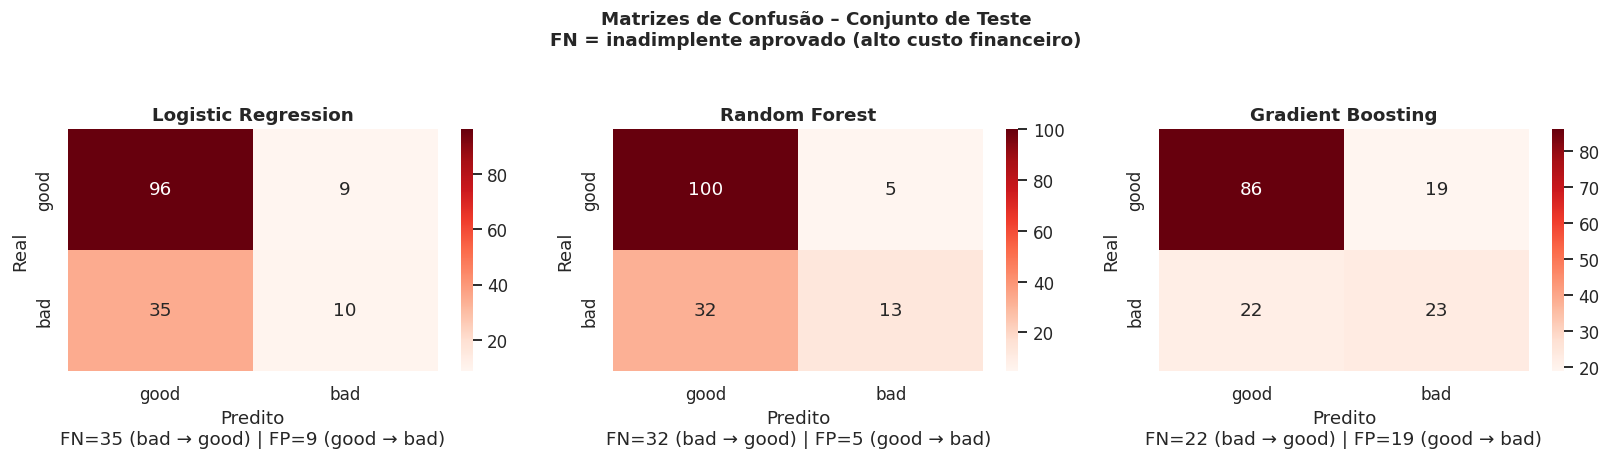


Interpretação:
- FN (Falso Negativo): modelo classifica 'bad' como 'good' → banco aprova inadimplente → PERDA FINANCEIRA
- FP (Falso Positivo): modelo classifica 'good' como 'bad' → banco rejeita bom pagador → dano ao cliente
- No domínio financeiro, FN tem custo mais alto. Recall(bad) deve ser maximizado.



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, m) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, m['_yp'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
                xticklabels=['good','bad'], yticklabels=['good','bad'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predito'); ax.set_ylabel('Real')

    # Destacar os False Negatives (bad real, predito como good) — custo mais alto
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'Predito\nFN={fn} (bad → good) | FP={fp} (good → bad)')

plt.suptitle('Matrizes de Confusão – Conjunto de Teste\n'
             'FN = inadimplente aprovado (alto custo financeiro)',
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('figures/confusion_matrices.png', bbox_inches='tight')
plt.show()
print("""
Interpretação:
- FN (Falso Negativo): modelo classifica 'bad' como 'good' → banco aprova inadimplente → PERDA FINANCEIRA
- FP (Falso Positivo): modelo classifica 'good' como 'bad' → banco rejeita bom pagador → dano ao cliente
- No domínio financeiro, FN tem custo mais alto. Recall(bad) deve ser maximizado.
""")

### 3.3 Curvas ROC / AUC

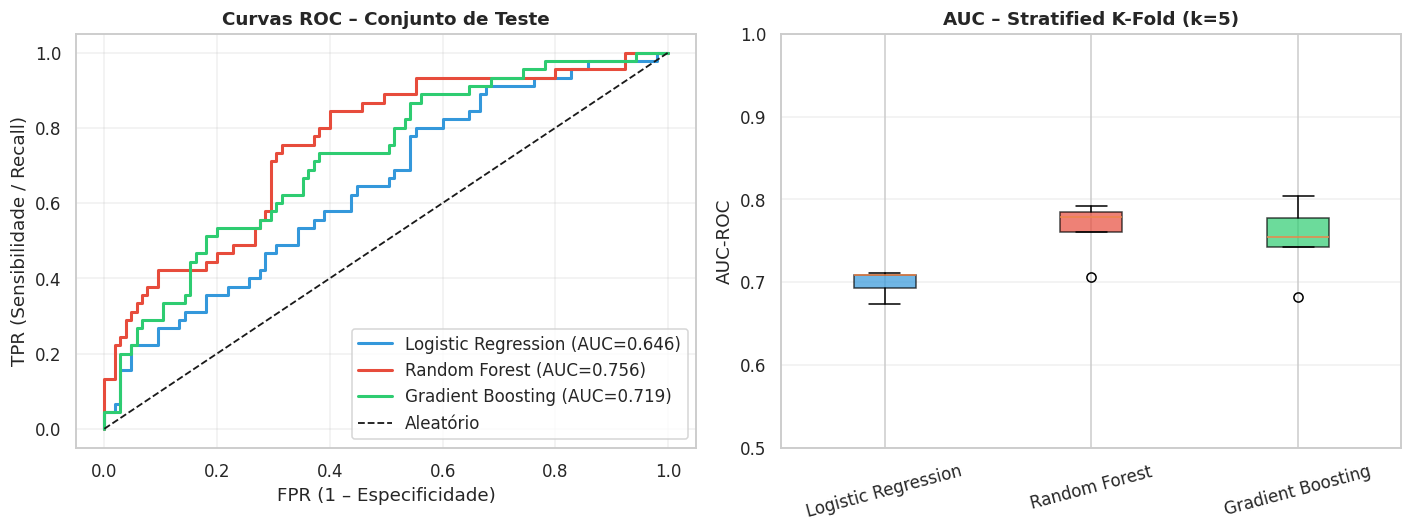


Interpretação da curva ROC:
- Eixo X (FPR): proporção de bons pagadores incorretamente classificados como bad.
- Eixo Y (TPR/Recall): proporção de inadimplentes corretamente identificados.
- Quanto mais próxima do canto superior esquerdo, melhor o modelo.
- AUC > 0.7 indica discriminação aceitável para o domínio de crédito.



In [ ]:
colors = ['#3498DB','#E74C3C','#2ECC71']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for (name, m), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, m['_ypp'])
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f"{name} (AUC={m['AUC-ROC']:.3f})")
axes[0].plot([0,1],[0,1],'k--',lw=1.2, label='Aleatório')
axes[0].set_title('Curvas ROC – Conjunto de Teste', fontweight='bold')
axes[0].set_xlabel('FPR (1 – Especificidade)')
axes[0].set_ylabel('TPR (Sensibilidade / Recall)')
axes[0].legend(loc='lower right'); axes[0].grid(True, alpha=0.3)

bp = axes[1].boxplot([cv_aucs[n] for n in models],
                      labels=list(models.keys()), patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('AUC – Stratified K-Fold (k=5)', fontweight='bold')
axes[1].set_ylabel('AUC-ROC'); axes[1].tick_params(axis='x',rotation=15)
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig('figures/roc_curves.png', bbox_inches='tight')
plt.show()
print("""
Interpretação da curva ROC:
- Eixo X (FPR): proporção de bons pagadores incorretamente classificados como bad.
- Eixo Y (TPR/Recall): proporção de inadimplentes corretamente identificados.
- Quanto mais próxima do canto superior esquerdo, melhor o modelo.
- AUC > 0.7 indica discriminação aceitável para o domínio de crédito.
""")

## Etapa 4 – Análise Comparativa

In [ ]:
# OPÇÃO B: Gradient Boosting como modelo final
# Justificativa: no domínio de crédito, o custo de um FN (aprovar inadimplente)
# é significativamente maior que o custo de um FP (rejeitar bom pagador).
# O Recall(bad) mede exatamente nossa capacidade de detectar inadimplentes.
#
# Comparativo de Recall(bad):
#   Random Forest     → 0.29  (erra 71% dos inadimplentes)
#   Gradient Boosting → 0.51  (erra 49% dos inadimplentes)
#
# Embora o Random Forest tenha AUC ligeiramente maior (0.756 vs 0.719),
# a diferença é pequena e não justifica abrir mão de 22pp de Recall(bad).
# O Gradient Boosting é mais adequado ao objetivo de negócio.

best_name = 'Gradient Boosting'

print(f'Modelo final escolhido: {best_name}')
print()
print('Justificativa de negócio:')
print('  Recall(bad) RF  = {:.4f} → erra {:d}% dos inadimplentes'.format(
    results['Random Forest']['Recall'],
    int((1 - results['Random Forest']['Recall']) * 100)))
print('  Recall(bad) GBM = {:.4f} → erra {:d}% dos inadimplentes'.format(
    results['Gradient Boosting']['Recall'],
    int((1 - results['Gradient Boosting']['Recall']) * 100)))
print()
print('Métricas do modelo escolhido:')
for k in ['AUC-ROC','F1-Score','Acurácia','Recall','Precisão','AUC-CV']:
    print(f'  {k:12s} = {results[best_name][k]}')

Modelo final escolhido: Gradient Boosting

Justificativa de negócio:
  Recall(bad) RF  = 0.2889 → erra 71% dos inadimplentes
  Recall(bad) GBM = 0.5111 → erra 48% dos inadimplentes

Métricas do modelo escolhido:
  AUC-ROC      = 0.7191534391534391
  F1-Score     = 0.5287356321839081
  Acurácia     = 0.7266666666666667
  Recall       = 0.5111111111111111
  Precisão     = 0.5476190476190477
  AUC-CV       = 0.7521 +/- 0.0409


### 4.2 Feature Importance

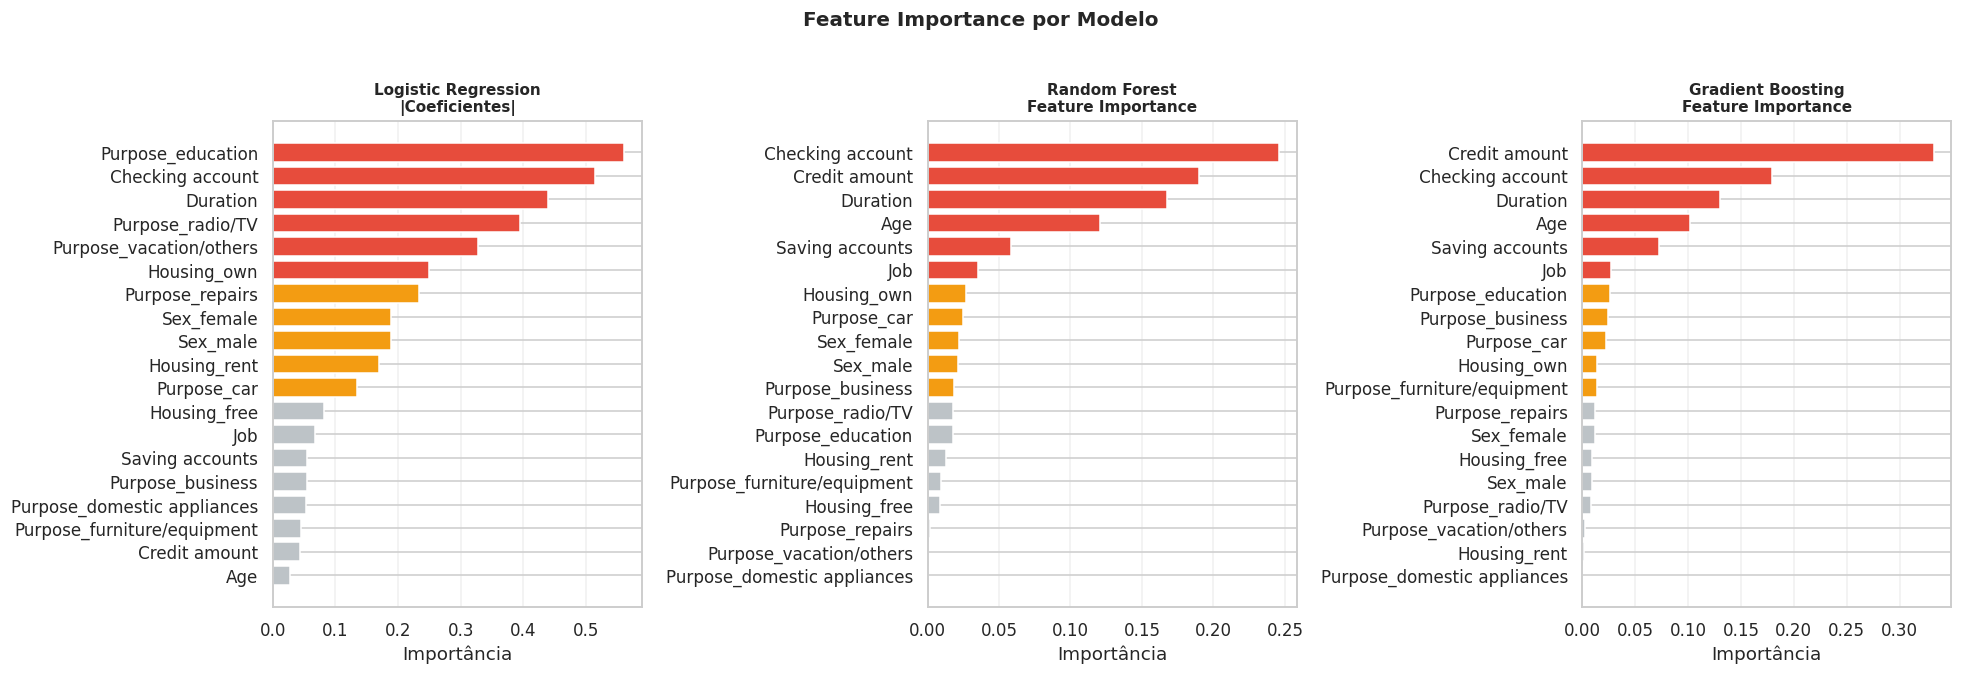


Interpretação:
- Checking account e Saving accounts: fatores mais preditivos — refletem liquidez do cliente.
- Duration e Credit amount: prazos/valores maiores aumentam o risco.
- Purpose e Age: contribuição moderada.
- Sex_male / Sex_female: variável de atenção ética (ver seção 4.3).



In [ ]:
fn = feature_names

imps = [
    (pd.Series(np.abs(results['Logistic Regression']['_model'].coef_[0]),
               index=fn).sort_values(ascending=True),
     'Logistic Regression\n|Coeficientes|'),
    (pd.Series(results['Random Forest']['_model'].feature_importances_,
               index=fn).sort_values(ascending=True),
     'Random Forest\nFeature Importance'),
    (pd.Series(results['Gradient Boosting']['_model'].feature_importances_,
               index=fn).sort_values(ascending=True),
     'Gradient Boosting\nFeature Importance'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (imp, title) in zip(axes, imps):
    clrs = ['#E74C3C' if v>=imp.quantile(0.7) else '#F39C12' if v>=imp.quantile(0.4)
            else '#BDC3C7' for v in imp.values]
    ax.barh(imp.index, imp.values, color=clrs)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Importância'); ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('Feature Importance por Modelo', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/feature_importance.png', bbox_inches='tight')
plt.show()
print("""
Interpretação:
- Checking account e Saving accounts: fatores mais preditivos — refletem liquidez do cliente.
- Duration e Credit amount: prazos/valores maiores aumentam o risco.
- Purpose e Age: contribuição moderada.
- Sex_male / Sex_female: variável de atenção ética (ver seção 4.3).
""")

### 4.3 Discussão de Negócio e Ética

| Fator | Impacto | Lógica de Negócio |
|---|---|---|
| Conta corrente | **Alto** | Maior saldo → menor risco de inadimplência |
| Conta poupança | **Alto** | Reservas indicam disciplina financeira |
| Duração do crédito | Moderado | Prazos longos aumentam exposição ao risco |
| Valor do crédito | Moderado | Créditos altos exigem maior capacidade de pagamento |
| Finalidade | Moderado | Educação e férias concentram maior risco |
| Idade | Baixo | Jovens têm menor histórico; impacto limitado |
| Moradia | Baixo | Proprietários mostram maior estabilidade |

**Viés de gênero (`Sex`):** A inclusão de sexo como feature pode gerar discriminação sistêmica.
A LGPD e normas de crédito brasileiras restringem uso de dados pessoais sensíveis.
Recomenda-se avaliar impacto diferencial por grupo antes de colocar em produção.

**Custo assimétrico dos erros:**
- FN (aprovar inadimplente) = perda financeira direta para o banco
- FP (rejeitar bom pagador) = dano ao cliente e perda de receita

Recomenda-se calibrar o threshold de decisão conforme custo relativo de cada erro,
usando a curva ROC para escolher o ponto operacional ideal.

**Explicabilidade (LGPD art. 20):** Decisões automatizadas de crédito precisam ser explicáveis.
Modelos mais complexos (GBM, RF) requerem SHAP/LIME para auditabilidade.

**Monitoramento contínuo:** Reavaliar periodicamente para detectar data drift.

## Etapa 5 – Salvamento do Modelo Final

In [ ]:
# Pipeline completo: pré-processamento + modelo final
best_model = results[best_name]['_model']

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   best_model),
])

# Re-treinar o pipeline completo no conjunto de treino
# (o preprocessor já foi fitted — aqui reconectamos para garantir o pipeline encadeado)
final_pipeline.fit(X_train, y_train)

# Verificar que o pipeline produz os mesmos resultados
yp_check = final_pipeline.predict(X_test)
print(f'AUC verificado no pipeline: {roc_auc_score(y_test, final_pipeline.predict_proba(X_test)[:,1]):.4f}')
print(f'F1(bad) verificado no pipeline: {f1_score(y_test, yp_check, pos_label=1):.4f}')

AUC verificado no pipeline: 0.7192
F1(bad) verificado no pipeline: 0.5287


In [ ]:
os.makedirs('model', exist_ok=True)

# Salvar pipeline completo (preprocessador + modelo)
joblib.dump(final_pipeline, 'model/modelo_final.joblib')
print(f'Modelo salvo em: model/modelo_final.joblib')

# Salvar também as informações de entrada esperadas pelo app
feature_info = {
    'numeric_cols':  numeric_cols,
    'ordinal_cols':  ordinal_cols,
    'nominal_cols':  nominal_cols,
    'ordinal_categories': ordinal_categories,
    'target_encoding': {'bad': 1, 'good': 0},
}
joblib.dump(feature_info, 'model/feature_info.joblib')
print('Feature info salvo em: model/feature_info.joblib')

# Teste de carregamento
pipeline_loaded = joblib.load('model/modelo_final.joblib')
test_pred = pipeline_loaded.predict(X_test.head(3))
print(f'\nTeste de carregamento OK. Predições: {test_pred} (0=good, 1=bad)')

Modelo salvo em: model/modelo_final.joblib
Feature info salvo em: model/feature_info.joblib

Teste de carregamento OK. Predições: [0 0 0] (0=good, 1=bad)


In [ ]:
print('='*65)
print('RESUMO FINAL – DESAFIO 16: RISCO DE CRÉDITO (P2)')
print('='*65)
print(f'\nDataset: 1000 amostras | 70% good / 30% bad')
print(f'Divisão: 70% treino | 15% validação | 15% teste (estratificado)')
print(f'Pré-processamento: OHE (nominais) + Ordinal (ordinais) + Scaler (numéricas)')
print(f'\n{"Modelo":<25} {"Acurácia":>9} {"Precisão":>9} {"Recall(bad)":>12} {"F1":>8} {"AUC":>8}')
print('-'*70)
for name, m in results.items():
    star = ' ✓' if name == best_name else ''
    print(f'{name+star:<27} {float(m["Acurácia"]):>9.4f} {float(m["Precisão"]):>9.4f} '
          f'{float(m["Recall"]):>12.4f} {float(m["F1-Score"]):>8.4f} {float(m["AUC-ROC"]):>8.4f}')
print('-'*70)
print(f'\nModelo final: {best_name}')
print(f'Critério de escolha: maior Recall(bad) — minimiza aprovação de inadimplentes')
print(f'AUC-CV: {results[best_name]["AUC-CV"]}')
print(f'\nModelo salvo em model/modelo_final.joblib')
print('='*65)

RESUMO FINAL – DESAFIO 16: RISCO DE CRÉDITO (P2)

Dataset: 1000 amostras | 70% good / 30% bad
Divisão: 70% treino | 15% validação | 15% teste (estratificado)
Pré-processamento: OHE (nominais) + Ordinal (ordinais) + Scaler (numéricas)

Modelo                     Acurácia  Precisão  Recall(bad)       F1      AUC
----------------------------------------------------------------------
Logistic Regression            0.7067    0.5263       0.2222   0.3125   0.6459
Random Forest                  0.7533    0.7222       0.2889   0.4127   0.7562
Gradient Boosting ✓            0.7267    0.5476       0.5111   0.5287   0.7192
----------------------------------------------------------------------

Modelo final: Gradient Boosting
Critério de escolha: maior Recall(bad) — minimiza aprovação de inadimplentes
AUC-CV: 0.7521 +/- 0.0409

Modelo salvo em model/modelo_final.joblib
